# Model red-noise Spikey light curve

This notebook is used to test the `UltraNest` modelling of the simulated light curves. It contains the following sections modelling:

- 4.1: White noise + Spikey fiducial
- 4.2: PlatoSim + Spikey fiducial

Last tested with PlatoSim version: `3.7.0-135-g178ce335`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Built-in
import os
import sys
import json
import datetime

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as c
from pathlib import Path
import ultranest
import ultranest.stepsampler
from ultranest import ReactiveNestedSampler
from ultranest.plot import cornerplot

import jax
from jax import random
from jax import numpy as jnp
sys.path.append('../src')
jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
numpyro.enable_x64()
numpyro.set_host_device_count(4)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_two_masses
import smbhb as smbhb
import utils as ut
import plots as pt
import bayes as bs

# Setup matplotlibrc
pt.setup()

# Increase width of notebook
from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

I/O paths for data

In [3]:
path = Path('../')
idir = path / 'data'
fdir = path / 'figures'
rdir = path / 'results'

Model parameters of Spikey (Hu+2020, Table 1)

In [4]:
z     = 0.918
t0    = 1.050  # [yr]
P     = 1.144  # [yr]
i     = 81.95  # [deg]
e     = 0.524  
w     = 84.63  # [deg]
logM1 = 7.4    # [log(M_Sun)]
logM2 = 6.7    # [log(M_Sun)]
L     = 0.89
alpha = 2.09
vz    = 0      # [cm/s]
tau   = 31     # [day]
SFinf = 9.25   # [ppt] (10 mmag = 9.25 ppt -> ut.mmag2ppt(10))
seed  = 12345

---
## 2. With DRW model
---

In [22]:
params = smbhb.model_params()
params.z     = z
params.t0    = t0
params.P     = P
params.i     = i
params.e     = e
params.w     = w
params.logM1 = logM1
params.logM2 = logM2
params.L     = L
params.alpha = alpha
params.vz    = vz
params.tau   = tau
params.sigma = 9.25
params.seed  = 12345

Initialise model with model parameters:

In [23]:
model = smbhb.model(params)

Generate the light curve model:

In [24]:
dm = model.light_curve(time, df=True)

Create data frame with model time series:

In [25]:
dv = pd.DataFrame()
dv['time'] = dm.time
dv['flux'] = dm.flux

Create data frame with model components and plot it:

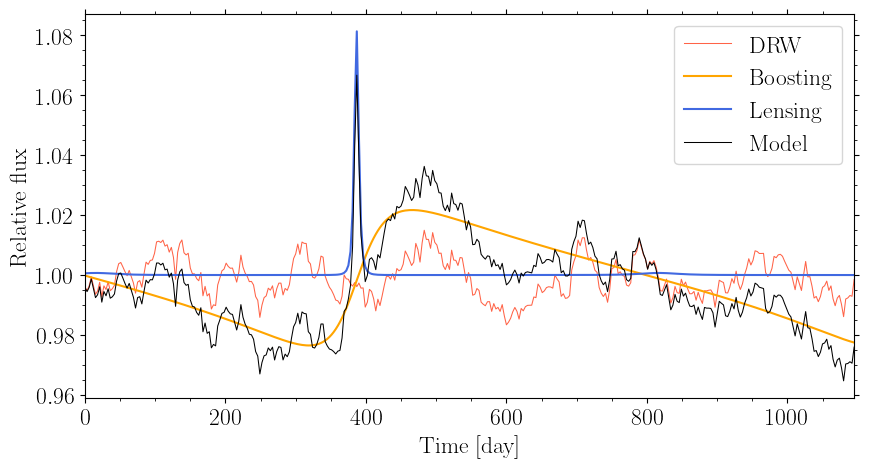

In [26]:
pt.plot_model(dm)
plt.show()

Add some Gaussian noise to to the model

In [27]:
df = dv.copy()
noise_level = 2e-3  # [pp1]
np.random.seed(seed)  # Reproducibility
df.flux += np.random.normal(0, noise_level, len(time))
df['flux_err'] = np.full(df.shape[0], noise_level)

Plot new noisy light curve

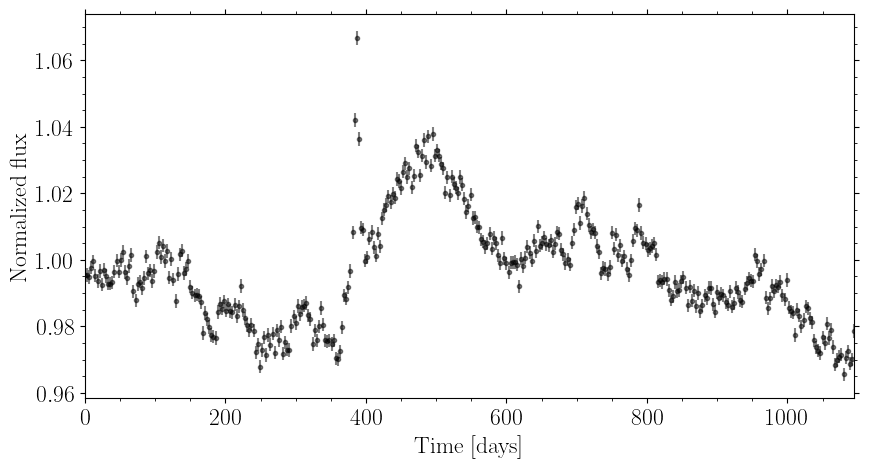

In [28]:
pt.plot_lc(df)
plt.show()

Arrays to be used for the rest of the analysis

In [29]:
time = df.time.to_numpy()
flux = df.flux.to_numpy()
flux_err = df.flux_err.to_numpy()

## UltraNest with uniform priors

Path to save results to

In [21]:
# path = rdir / 'spikey_whitenoise_test0'

Define priors  UltraNest + SMBHB:

In [30]:
filename = 'spikey_rednoise_test0'
priors = bs.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [P*0.95, P*1.05]
priors.i     = [70, 90]
priors.e     = [e*0.9, e*1.1]
priors.w     = [w*0.9, w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [alpha*0.9, alpha*1.1]
priors.vz    = vz
# [ultranest] Explored until L=-1e+04  -10335.17 [-10336.0774..-10336.0769]*| it/evals=13930/1019223 eff=1.3673% N=400 
# [ultranest] Likelihood function evaluations: 1019640
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -1.037e+04 +- 0.2103
# [ultranest] Effective samples strategy satisfied (ESS = 3072.4, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.15 to 0.55, need <0.5)
# [ultranest]   logZ error budget: single: 0.26 bs:0.21 tail:0.01 total:0.21 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:04:02.164283 [h:mm:ss]

# logZ = -10366.062 +- 0.422
#   single instance: logZ = -10366.062 +- 0.257
#   bootstrapped   : logZ = -10366.086 +- 0.421
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.93% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.05304│ ▁ ▁ ▁▁▁▁▁▁▂▂▂▃▄▅▆▇▆▇▇▇▆▆▅▄▃▂▁▁▁▁▁▁▁▁▁ │1.06115    1.05739 +- 0.00095
#     P                   : 1.1337│ ▁▁▁▁▁▁▁▁▁▂▂▂▃▄▄▆▆▇▇▇▇▆▇▅▄▃▂▂▂▁▁▁▁▁▁▁▁ │1.1623    1.1485 +- 0.0035
#     i                   : 81.40 │ ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▅▆▆▆▇▇▇▆▅▄▃▂▂▁▁▁▁▁▁   ▁ │83.47     82.43 +- 0.23
#     e                   : 0.5103│ ▁▁▁▁▁▁▁▁▁▁▂▂▃▄▄▅▆▇▇▇▇▆▅▅▃▃▂▂▁▁▁▁▁▁▁▁▁ │0.5511    0.5311 +- 0.0047
#     w                   : 86.67 │ ▁  ▁▁▁▁▁▁▁▁▂▂▄▄▅▆▇▇▇▇▆▆▅▅▃▃▂▁▁▁▁▁▁▁▁▁ │91.59     89.25 +- 0.58
#     logM1               : 7.072 │ ▁  ▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▆▅▄▃▂▂▂▁▁▁▁▁▁▁ ▁ │7.388     7.232 +- 0.035
#     logM2               : 5.00  │▃▃▃▃▃▃▃▄▃▃▃▄▃▄▄▄▄▄▅▄▄▄▅▅▅▆▇▇▅▇▇▆▅▂▁▁▁▁ │6.85      5.95 +- 0.45
#     L                   : 0.893 │ ▁▁   ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▃▄▄▅▅▆▆▇│1.000     0.985 +- 0.013
#     alpha               : 1.970 │ ▁   ▁▁ ▁▁▁▁▁▁▁▁▂▃▄▅▅▆▇▇▇▇▇▆▅▄▃▂▁▁▁▁▁▁ │2.270     2.154 +- 0.033

In [93]:
filename = 'spikey_rednoise_test1'
priors = bs.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [0, 3]
priors.i     = [70, 90]
priors.e     = [e*0.9, e*1.1]
priors.w     = [w*0.9, w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [alpha*0.9, alpha*1.1]
priors.vz    = vz
# [ultranest] Explored until L=-1e+04  -10335.14 [-10335.9528..-10335.9525]*| it/evals=15560/1116445 eff=1.3942% N=400 0 
# [ultranest] Likelihood function evaluations: 1116844
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -1.037e+04 +- 0.1789
# [ultranest] Effective samples strategy satisfied (ESS = 3125.4, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
# [ultranest]   logZ error budget: single: 0.28 bs:0.18 tail:0.01 total:0.18 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:04:26.393577 [h:mm:ss]

# logZ = -10370.030 +- 0.435
#   single instance: logZ = -10370.030 +- 0.277
#   bootstrapped   : logZ = -10370.033 +- 0.435
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.87% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.05316│ ▁▁▁ ▁▁▁▁▁▁▁▂▃▄▅▆▇▇▇▆▆▅▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁ │1.06156    1.05739 +- 0.00092
#     P                   : 1.1336│ ▁ ▁▁▁▁▁▁▁▂▂▂▃▅▆▆▇▇▇▇▇▅▄▃▃▂▂▁▁▁▁▁▁▁  ▁ │1.1642    1.1487 +- 0.0033
#     i                   : 81.41 │ ▁▁ ▁▁▁▁▁▁▁▁▂▂▃▄▆▆▇▇▇▇▇▆▆▄▃▂▂▁▁▁▁▁▁▁▁▁ │83.37     82.44 +- 0.22
#     e                   : 0.5109│ ▁▁▁▁▁▁▁▁▁▁▂▂▂▃▄▄▅▆▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁ │0.5497    0.5312 +- 0.0045
#     w                   : 86.78 │ ▁▁ ▁▁▁▁▁▁▁▁▃▃▄▅▇▇▇▇▆▆▄▄▃▃▂▂▁▁▁▁▁▁▁ ▁▁ │91.86     89.25 +- 0.56
#     logM1               : 7.097 │ ▁▁▁▁▁▁▁▁▁▂▃▃▄▅▅▆▇▇▇▇▇▇▆▄▃▃▂▂▁▁▁▁▁▁▁▁▁ │7.365     7.230 +- 0.034
#     logM2               : 5.00  │▂▃▂▂▂▃▃▃▃▃▃▃▃▄▄▅▃▅▄▅▆▆▇▅▇▇▇▇▆▇▅▃▂▁▁▁▁▁ │6.92      5.97 +- 0.41
#     L                   : 0.899 │ ▁▁ ▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▃▄▄▅▅▅▇▇▇│1.000     0.985 +- 0.013
#     alpha               : 1.980 │ ▁  ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▄▅▆▇▇▇▇▇▅▅▄▃▂▂▁▁▁▁▁ │2.263     2.153 +- 0.032

In [34]:
filename = 'spikey_rednoise_test2'
priors = bs.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [0, 3]
priors.i     = [70, 90]
priors.e     = [e*0.9, e*1.1]
priors.w     = [w*0.9, w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [alpha*0.9, alpha*1.1]
priors.vz    = vz
# [ultranest] Explored until L=-1e+04  -10335.14 [-10335.9528..-10335.9525]*| it/evals=15560/1116445 eff=1.3942% N=400 0 
# [ultranest] Likelihood function evaluations: 1116844
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -1.037e+04 +- 0.1789
# [ultranest] Effective samples strategy satisfied (ESS = 3125.4, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
# [ultranest]   logZ error budget: single: 0.28 bs:0.18 tail:0.01 total:0.18 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:04:26.393577 [h:mm:ss]

# logZ = -10370.030 +- 0.435
#   single instance: logZ = -10370.030 +- 0.277
#   bootstrapped   : logZ = -10370.033 +- 0.435
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.87% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.05316│ ▁▁▁ ▁▁▁▁▁▁▁▂▃▄▅▆▇▇▇▆▆▅▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁ │1.06156    1.05739 +- 0.00092
#     P                   : 1.1336│ ▁ ▁▁▁▁▁▁▁▂▂▂▃▅▆▆▇▇▇▇▇▅▄▃▃▂▂▁▁▁▁▁▁▁  ▁ │1.1642    1.1487 +- 0.0033
#     i                   : 81.41 │ ▁▁ ▁▁▁▁▁▁▁▁▂▂▃▄▆▆▇▇▇▇▇▆▆▄▃▂▂▁▁▁▁▁▁▁▁▁ │83.37     82.44 +- 0.22
#     e                   : 0.5109│ ▁▁▁▁▁▁▁▁▁▁▂▂▂▃▄▄▅▆▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁ │0.5497    0.5312 +- 0.0045
#     w                   : 86.78 │ ▁▁ ▁▁▁▁▁▁▁▁▃▃▄▅▇▇▇▇▆▆▄▄▃▃▂▂▁▁▁▁▁▁▁ ▁▁ │91.86     89.25 +- 0.56
#     logM1               : 7.097 │ ▁▁▁▁▁▁▁▁▁▂▃▃▄▅▅▆▇▇▇▇▇▇▆▄▃▃▂▂▁▁▁▁▁▁▁▁▁ │7.365     7.230 +- 0.034
#     logM2               : 5.00  │▂▃▂▂▂▃▃▃▃▃▃▃▃▄▄▅▃▅▄▅▆▆▇▅▇▇▇▇▆▇▅▃▂▁▁▁▁▁ │6.92      5.97 +- 0.41
#     L                   : 0.899 │ ▁▁ ▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▃▄▄▅▅▅▇▇▇│1.000     0.985 +- 0.013
#     alpha               : 1.980 │ ▁  ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▄▅▆▇▇▇▇▇▅▅▄▃▂▂▁▁▁▁▁ │2.263     2.153 +- 0.032

In [16]:
filename = 'spikey_rednoise_test3'
priors = bs.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [0, 3]
priors.i     = [0, 90]
priors.e     = [e*0.5, e*1.1]
priors.w     = [w*0.9, w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [alpha*0.9, alpha*1.1]
priors.vz    = vz

In [31]:
params_input   = [t0, P, i, e, w, logM1, logM2, L, alpha]
params_names   = ['t0', 'P', 'i', 'e', 'w', 'logM1', 'logM2', 'L', 'alpha']
params_wrapped = [False] * len(params_names)

def prior_transform(cube):
    p = cube.copy()
    p[0] = cube[0] * (priors.t0[1]    - priors.t0[0])    + priors.t0[0]
    p[1] = cube[1] * (priors.P[1]     - priors.P[0])     + priors.P[0] 
    p[2] = cube[2] * (priors.i[1]     - priors.i[0])     + priors.i[0] 
    p[3] = cube[3] * (priors.e[1]     - priors.e[0])     + priors.e[0] 
    p[4] = cube[4] * (priors.w[1]     - priors.w[0])     + priors.w[0] 
    p[5] = cube[5] * (priors.logM1[1] - priors.logM1[0]) + priors.logM1[0] 
    p[6] = cube[6] * (priors.logM2[1] - priors.logM2[0]) + priors.logM2[0] 
    p[7] = cube[7] * (priors.L[1]     - priors.L[0])     + priors.L[0] 
    p[8] = cube[8] * (priors.alpha[1] - priors.alpha[0]) + priors.alpha[0] 
    return p
    
def log_likelihood(p):       
    flux_model = smbhb.smbhb(
        time  = time,
        z     = z,
        t0    = p[0],
        P     = p[1],
        i     = p[2],
        e     = p[3],
        w     = p[4],
        logM1 = p[5],
        logM2 = p[6],
        L     = p[7],
        # alpha = alpha,
        alpha = p[8],
        vz    = vz,
        tau   = None,
        sigma = None,
        seed  = None
    )
    return -0.5 * np.nansum(((flux_model - flux) / flux_err)**2)

sampler = ReactiveNestedSampler(
    params_names,
    log_likelihood, 
    prior_transform,
    wrapped_params = params_wrapped,
    log_dir        = rdir / filename,
    resume         = 'overwrite',
)

sampler.stepsampler = ultranest.stepsampler.RegionSliceSampler(
    nsteps          = 1000,
    max_nsteps      = 1000,
    adaptive_nsteps = 'move-distance',
)

Run UltraNest on our simulated light curve:

In [ ]:
# Run nested sampling
tic  = datetime.datetime.now()
result = sampler.run(min_num_live_points=400)
toc  = datetime.datetime.now()
print(f'Execution time: {toc-tic} [h:mm:ss]')
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...


In [ ]:
# result, sampler = bs.run_ultranest(df, priors, rdir, nsteps=1000, live_points=400)

Make conerplot and compare to input values

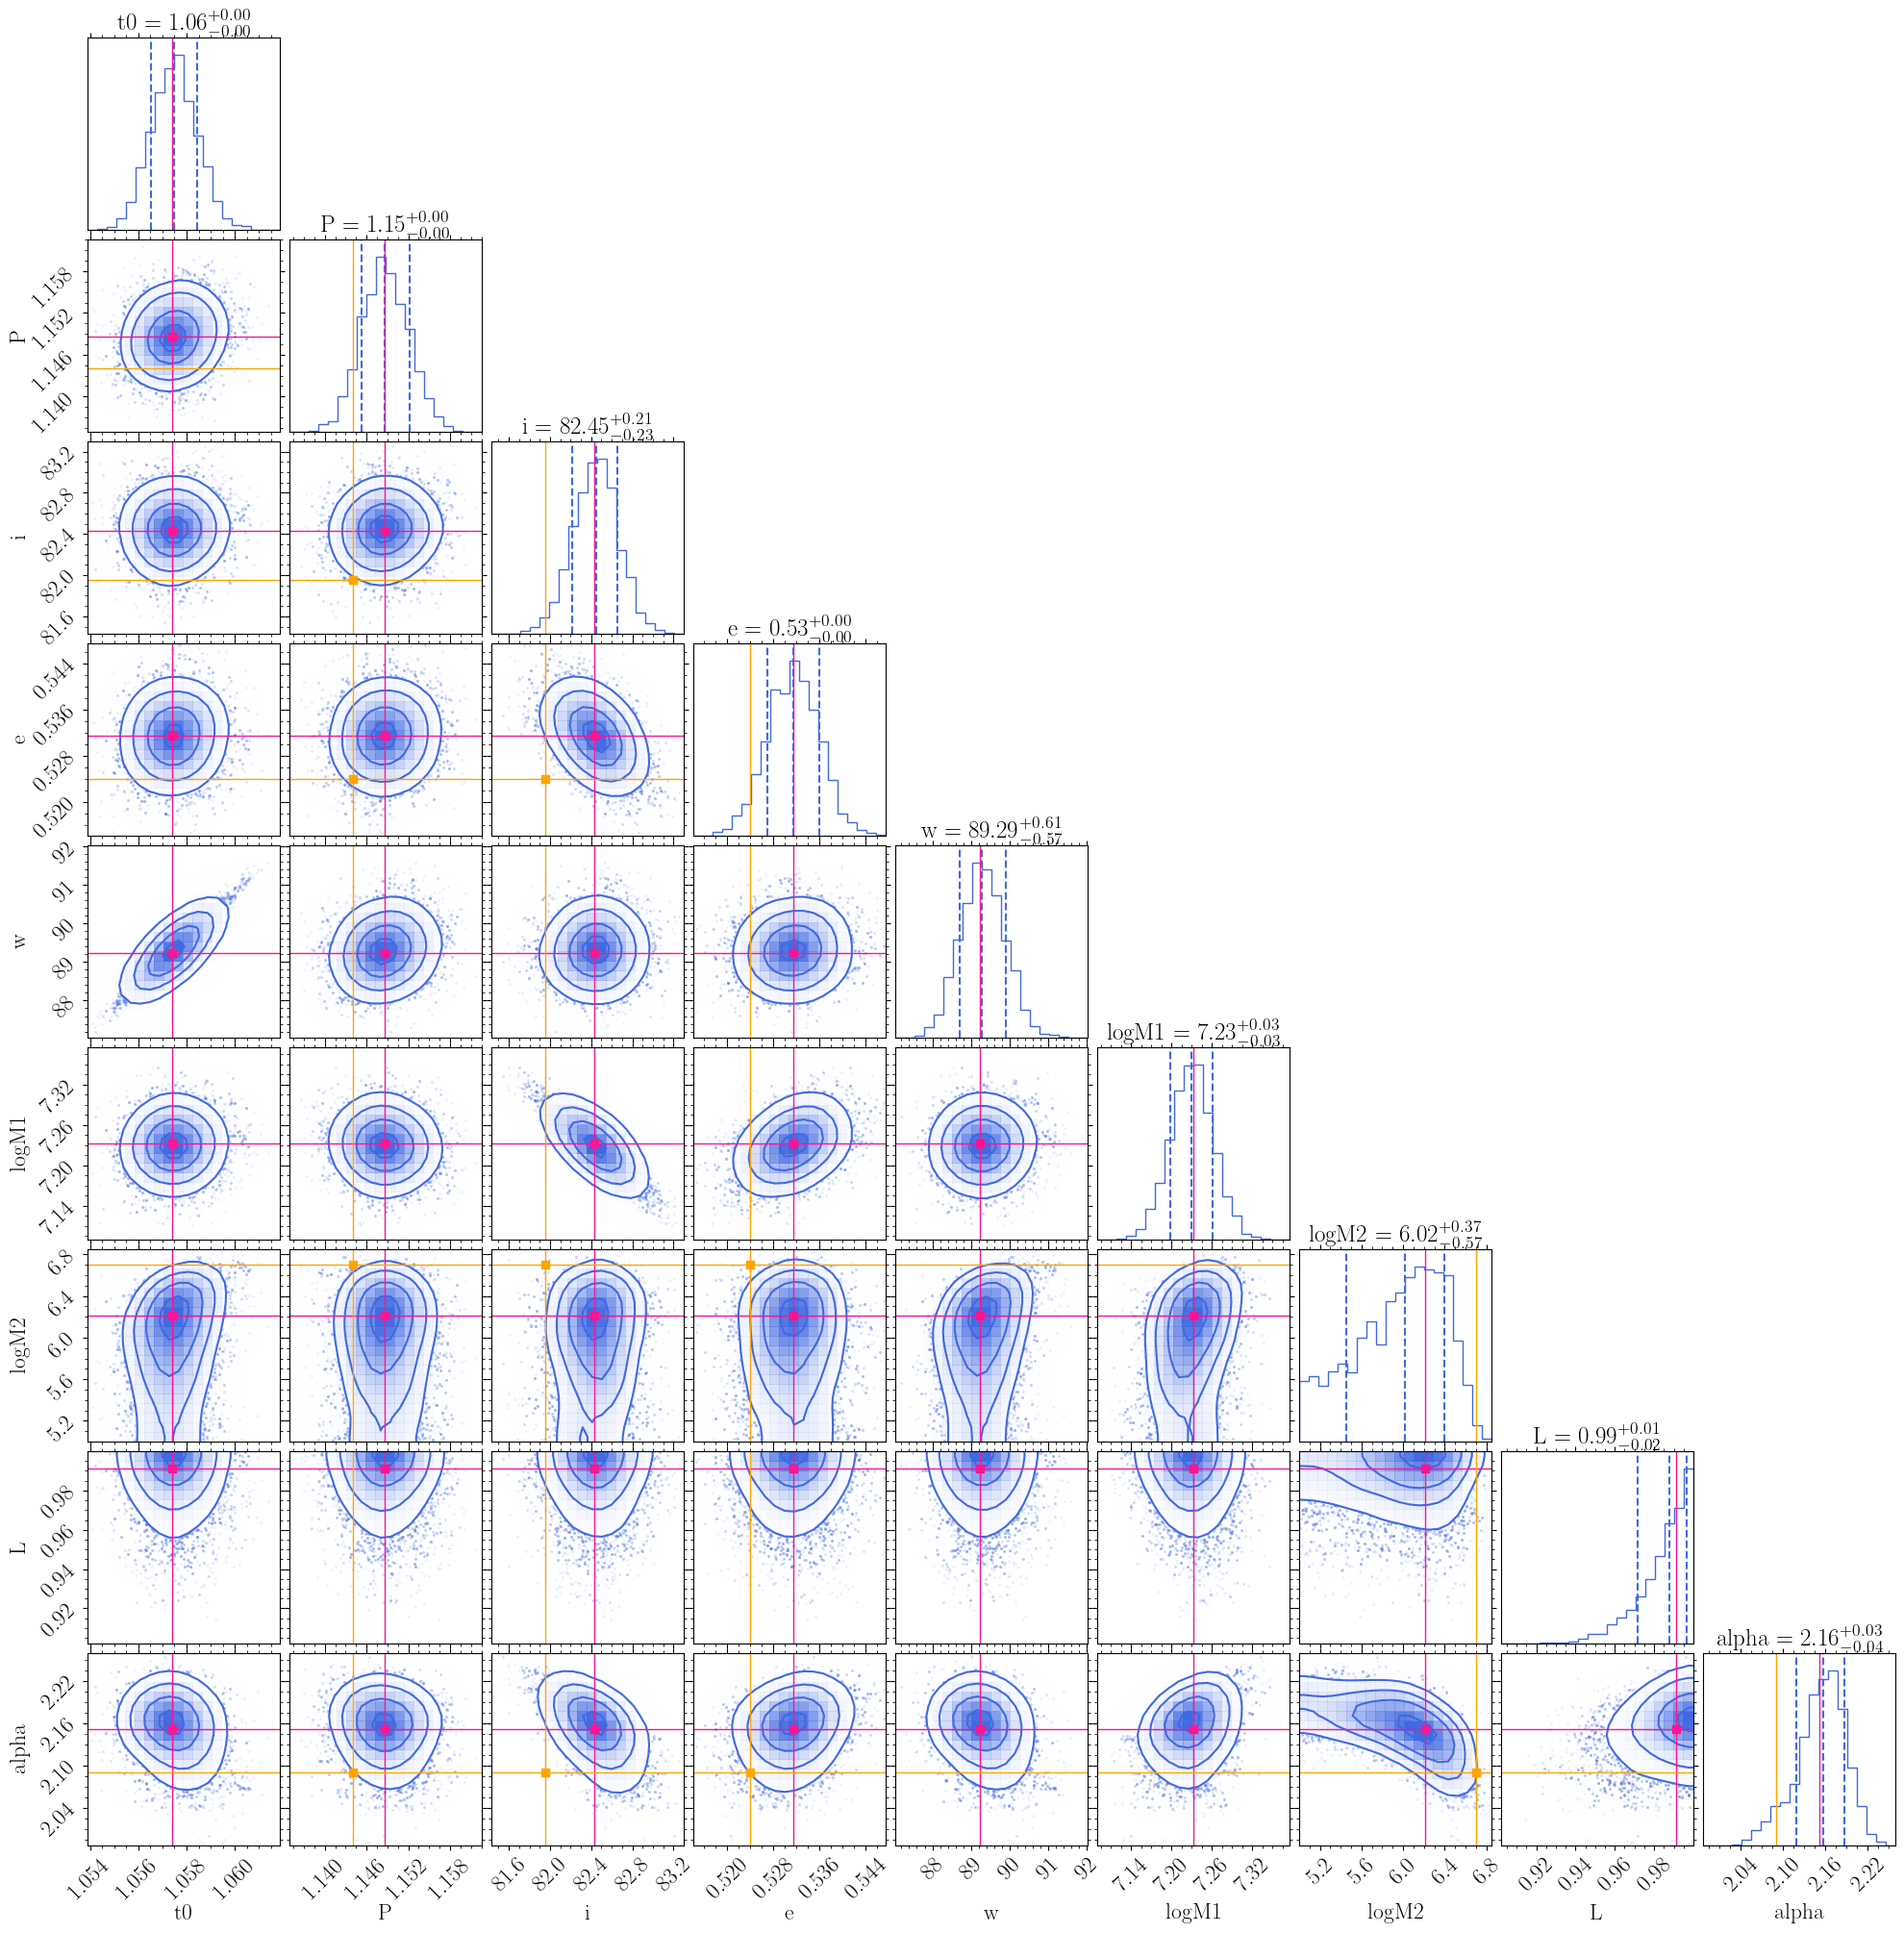

In [19]:
fig = pt.plot_corner(result, bestfit='maximum', values_input=params_input);
fig.savefig(fdir / f'{filename}_cornerplot.png', bbox_inches='tight', dpi=200)

Generate the light curve model:

In [20]:
dm = bs.bestfit_model(time, params, result)

Plot best-fit light curve

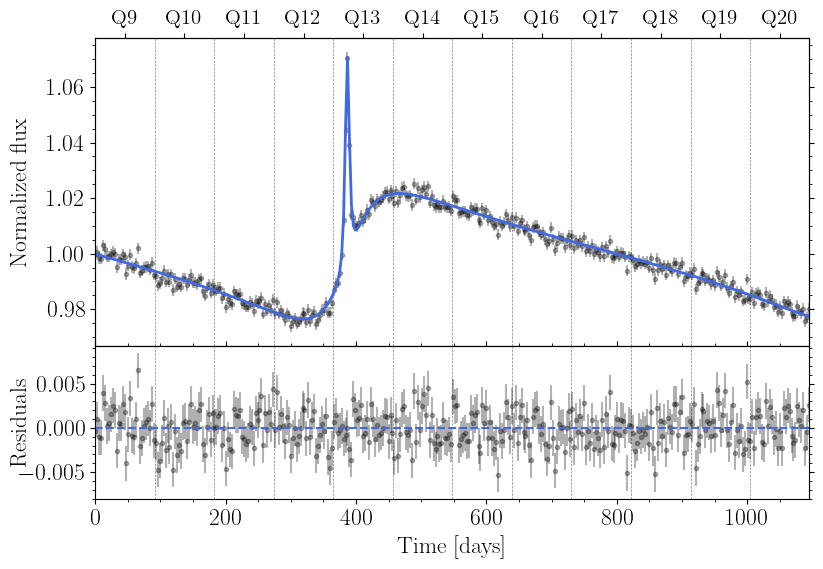

In [21]:
fig, ax = pt.plot_result(df, dm, Q0=9, alpha=0.3, figsize=(8.5, 6));
fig.savefig(fdir / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200)